# Agrupamiento No Supervisado: Perfiles Delictivos Estatales

El objetivo de este módulo es identificar segmentos, perfiles y patrones latentes en la incidencia delictiva de las 32 entidades federativas de México mediante técnicas de agrupamiento no supervisado utilizando el algoritmo K-Means.

A diferencia de un análisis basado en el volumen total de delitos, el cual puede verse influenciado por factores como el tamaño poblacional o la concentración urbana de cada entidad, este estudio se centra en la proporción de participación de los siete Bienes Jurídicos Afectados registrados en cada estado. De esta forma, el análisis busca caracterizar la composición relativa de la actividad delictiva en cada entidad, independientemente de su magnitud absoluta.

Bajo este enfoque, la pregunta principal que guía el análisis es: *¿Qué tipo de delincuencia predomina en cada entidad federativa y qué estados comparten perfiles delictivos similares?*

## Preparación de los Datos y Construcción de la Matriz de Proporciones

Con el fin de identificar patrones en la composición de la incidencia delictiva y evitar que los agrupamientos estuvieran determinados principalmente por el tamaño poblacional o el volumen total de delitos de cada entidad, se implementaron las siguientes transformaciones mediante `CrimeClusteringPipeline`:

- **Agrupación por Bien Jurídico:** Los distintos tipos y subtipos de delitos se agruparon en las siete categorías de Bien Jurídico Afectado definidas en el conjunto de datos. Esto permitió reducir la dimensionalidad y obtener una representación más interpretable del fenómeno delictivo.

- **Normalización por Fila (Proporciones):** Para cada entidad federativa se calculó la proporción que representa cada bien jurídico respecto al total de delitos registrados en dicha entidad.
  $$p_i = \frac{\text{Delitos}_i}{\sum_{j} \text{Delitos}_j}$$
  De esta manera, cada estado quedó representado por un vector de siete proporciones cuya suma es igual a uno, permitiendo comparar la estructura relativa de la incidencia delictiva independientemente de su magnitud absoluta.
  
- **Estandarización (StandardScaler):** Aunque todas las variables fueron previamente transformadas a proporciones, los distintos bienes jurídicos presentan niveles de variabilidad diferentes entre entidades federativas. La estandarización permite que cada dimensión contribuya de forma equilibrada al cálculo de las distancias euclidianas utilizadas por K-Means, evitando que las categorías con mayor dispersión dominen el proceso de agrupamiento.


In [1]:
import sys
from pathlib import Path

# Resuelve el problema de las ubicaciones de los scripts
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data import DataRepository
from src.clustering import CrimeClusteringPipeline

# Tema visual por defecto del proyecto.
sns.set_theme(style=config.SEABORN_THEME, palette=config.PLOT_PALETTE)

# Cargar el dataset limpio
repo = DataRepository(config.PROCESSED_CSV)
dataframe = repo.load()

# Inicializar el pipeline de agrupamiento
clustering_pipe = CrimeClusteringPipeline()

# Transformar los datos y generar la matriz estandarizada
matrix_pct = clustering_pipe.fit_transform(dataframe)

[Clustering] Matriz macro preparada con 32 estados y 7 variables (Bienes Jurídicos).
[Clustering] El plano visual (PCA 2D) captura el 55.32% de la varianza total de estas categorías.


### Consideración sobre la Dimensionalidad y Visualización (PCA)

Con el propósito de visualizar los resultados del agrupamiento, se empleó un modelo de Análisis de Componentes Principales (PCA) configurado con dos componentes principales.

Es importante destacar que el algoritmo K-Means fue entrenado utilizando las siete variables originales estandarizadas, conservando así la totalidad de la información disponible para el proceso de agrupamiento. El PCA se utilizó únicamente como una técnica de reducción de dimensionalidad para representar gráficamente los resultados en un plano bidimensional.

La proyección obtenida mediante las dos primeras componentes principales explica el 55.32% de la varianza total de los datos. Si bien esta representación no captura la totalidad de la estructura presente en el espacio original de siete dimensiones, proporciona una aproximación visual adecuada de los patrones principales y permite interpretar de forma intuitiva la separación entre los grupos identificados por K-Means. La información restante permanece contenida en las dimensiones no representadas gráficamente, pero sí fue considerada durante el proceso de agrupamiento.

## Selección del Número Óptimo de Grupos (K)
Para determinar la estructura de agrupamiento más adecuada de las entidades federativas, se evaluaron simultáneamente el Método del Codo (Inercia) y la evolución del Coeficiente de Silueta en un rango de $K \in [2, 8]$.

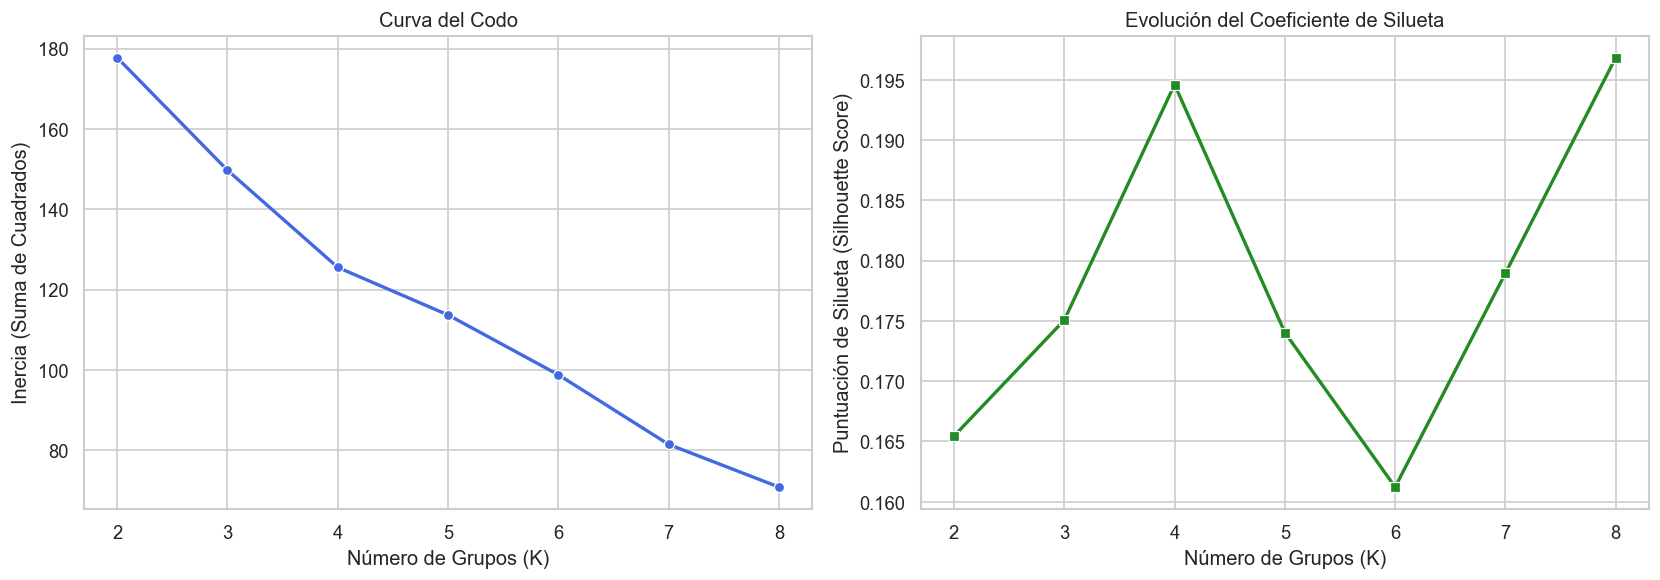

In [2]:
# Calcular las métricas de Inercia y Silueta para rangos de K del 2 al 8
metrics = clustering_pipe.evaluate_k_options(max_k=8)

# Configurar el lienzo para mostrar ambas gráficas una al lado de la otra
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=config.PLOT_DPI)

# Gráfica izquierda: Método del Codo (Inercia)
sns.lineplot(x=metrics["k"], y=metrics["inertia"], marker="o", ax=axes[0], color="royalblue", linewidth=2)
axes[0].set_title("Curva del Codo")
axes[0].set_xlabel("Número de Grupos (K)")
axes[0].set_ylabel("Inercia (Suma de Cuadrados)")
axes[0].grid(True)

# Gráfica derecha: Evolución de la Silueta (Silhouette Score)
sns.lineplot(x=metrics["k"], y=metrics["silhouette"], marker="s", ax=axes[1], color="forestgreen", linewidth=2)
axes[1].set_title("Evolución del Coeficiente de Silueta")
axes[1].set_xlabel("Número de Grupos (K)")
axes[1].set_ylabel("Puntuación de Silueta (Silhouette Score)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Criterio de Selección

1. **Coeficiente de Silueta.** Podemos observar un máximo local claramente definido en K=4, indicando una buena combinación entre cohesión y separación de los grupos. Aunque el valor máximo absoluto se alcanza en K=8, la mejora respecto a K=4 es poco significativa.

2. **Método del Codo.** La curva de inercia presenta una desaceleración apreciable en su tasa de disminución alrededor de K=4, sugiriendo que incrementos posteriores en el número de clusters producen beneficios progresivamente menores.

Con base en ambos criterios seleccionamos K = 4 como la configuración final del modelo. Esta elección proporciona un equilibrio adecuado entre calidad estadística e interpretabilidad, permitiendo identificar perfiles delictivos diferenciados sin fragmentar excesivamente el conjunto de 32 entidades federativas analizadas.


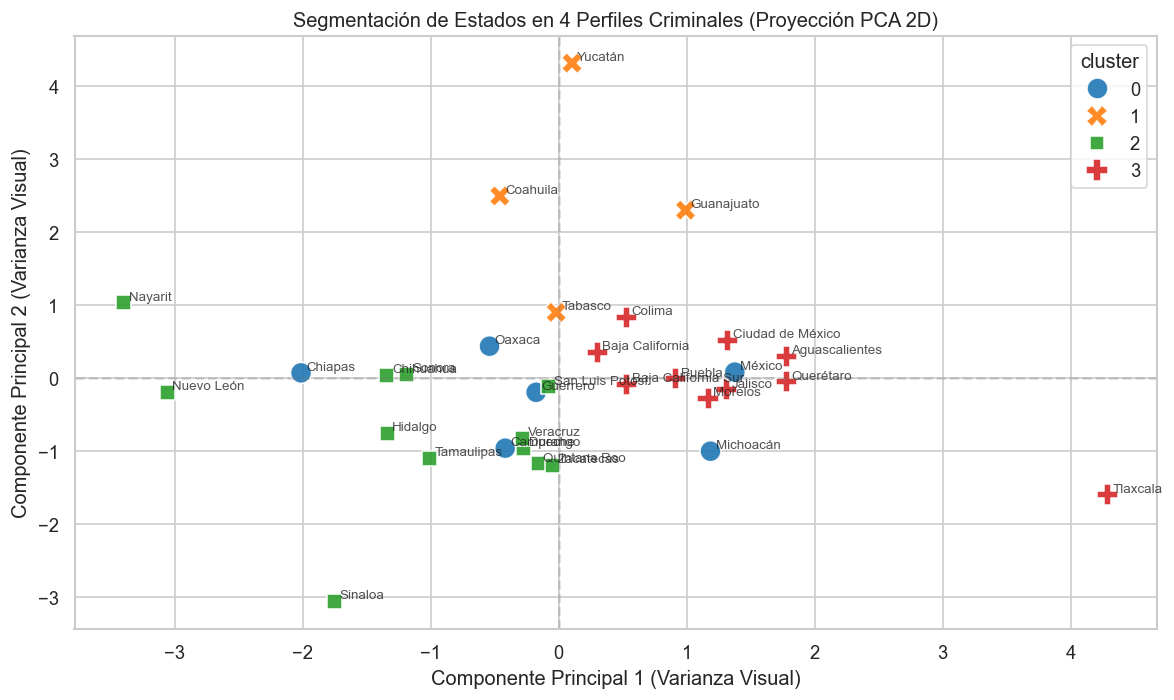

In [3]:
N_CLUSTERS_OPTIMO = 4

# Entrenar el modelo final en 7D y recuperar coordenadas PCA para graficar
df_clusters = clustering_pipe.fit_final_model(n_clusters=N_CLUSTERS_OPTIMO)

# Construir la visualización del Scatter Plot
plt.figure(figsize=config.PLOT_FIGSIZE, dpi=config.PLOT_DPI)

sns.scatterplot(
    data=df_clusters, 
    x="pca_1", 
    y="pca_2", 
    hue="cluster", 
    palette="tab10", 
    s=160, 
    style="cluster",
    alpha=0.9
)

# Etiquetar cada punto con el nombre de su respectivo estado
for i in range(len(df_clusters)):
    plt.text(
        x=df_clusters["pca_1"][i] + 0.04, 
        y=df_clusters["pca_2"][i] + 0.04, 
        s=df_clusters["entidad"][i], 
        fontsize=8,
        alpha=0.8
    )

plt.title(f"Segmentación de Estados en {N_CLUSTERS_OPTIMO} Perfiles Criminales (Proyección PCA 2D)")
plt.xlabel("Componente Principal 1 (Varianza Visual)")
plt.ylabel("Componente Principal 2 (Varianza Visual)")

# Líneas de referencia en el origen
plt.axhline(0, color="grey", linestyle="--", alpha=0.3)
plt.axvline(0, color="grey", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Recuperamos la matriz original de porcentajes por estado
matrix_pct = clustering_pipe.prepare_matrix(dataframe)

# Pegamos la columna del cluster que calculó el modelo
matrix_pct['cluster'] = df_clusters.set_index('entidad')['cluster']

# Calculamos el promedio de cada delito para cada uno de los 4 grupos
resumen_clusters = matrix_pct.groupby('cluster').mean()

# Multiplicamos por 100 para visualizarlo como porcentaje limpio y transponemos para leerlo mejor
resumen_porcentual = (resumen_clusters * 100).round(2).T

print("PORCENTAJE PROMEDIO DE DELITOS EN CADA CLUSTER")
resumen_porcentual

PORCENTAJE PROMEDIO DE DELITOS EN CADA CLUSTER


cluster,0,1,2,3
bien_juridico_afectado,,,,
El patrimonio,44.02,37.44,42.74,55.04
La familia,10.57,14.54,19.93,11.17
La libertad y la seguridad sexual,3.86,2.22,3.77,2.83
La sociedad,0.57,0.53,0.26,0.43
La vida y la Integridad corporal,18.74,11.61,13.47,11.08
Libertad personal,1.05,0.37,1.93,0.69
Otros bienes jurídicos afectados (del fuero común),21.19,33.29,17.89,18.76


## Justificación del Algoritmo Seleccionado

Se seleccionó K-Means como algoritmo de agrupamiento debido a que las variables utilizadas corresponden a proporciones normalizadas de incidencia delictiva, generando un espacio de características continuo en el que la distancia euclidiana constituye una medida adecuada de similitud. Adicionalmente, el análisis se realiza sobre un conjunto reducido de observaciones (32 entidades federativas), situación en la que los métodos basados en densidad pueden presentar una alta sensibilidad a la configuración de parámetros y producir agrupamientos poco estables. Finalmente, K-Means genera centroides explícitos para cada grupo, lo que permite caracterizar e interpretar los perfiles criminológicos resultantes mediante el comportamiento promedio de los bienes jurídicos afectados en cada cluster.